In [62]:
import warnings
warnings.filterwarnings('ignore')

In [63]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [64]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [65]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,245,Democrats
1,211,Republicans
2,235,Democrats
3,229,Democrats
4,221,Democrats
...,...,...
19995,227,Democrats
19996,231,Democrats
19997,232,Democrats
19998,237,Democrats


In [66]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,150,1,0.005,Republicans
1,151,1,0.005,Republicans
2,152,1,0.005,Republicans
3,159,1,0.005,Republicans
4,161,1,0.005,Republicans


In [67]:
np.unique(seat_sims['seats']).shape[0]

191

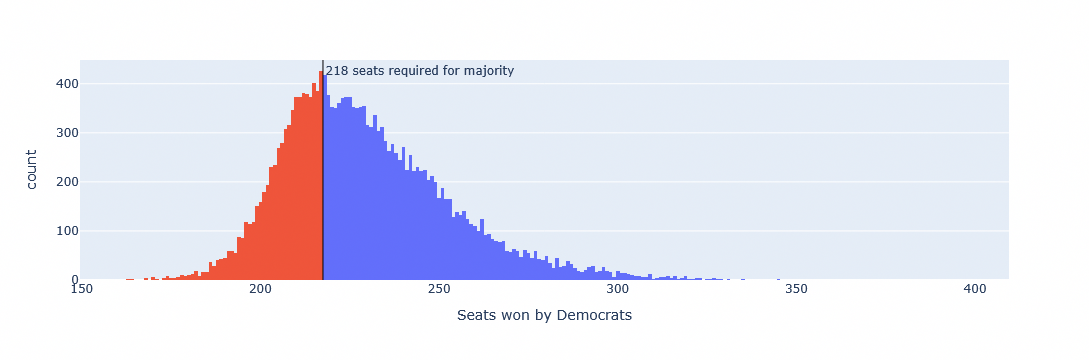

In [68]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [69]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [70]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,...,19500,19501,19502,19503,19504,19505,19506,19507,19508,19509,19510,19511,19512,19513,19514,19515,19516,19517,19518,19519,19520,19521,19522,19523,19524,19525,19526,19527,19528,19529,19530,19531,19532,19533,19534,19535,19536,19537,19538,19539,19540,19541,19542,19543,19544,19545,19546,19547,19548,19549,19550,19551,19552,19553,19554,19555,19556,19557,19558,19559,19560,19561,19562,19563,19564,19565,19566,19567,19568,19569,19570,19571,19572,19573,19574,19575,19576,19577,19578,19579,19580,19581,19582,19583,19584,19585,19586,19587,19588,19589,19590,19591,19592,19593,19594,19595,19596,19597,19598,19599,19600,19601,19602,19603,19604,19605,19606,19607,19608,19609,19610,19611,19612,19613,19614,19615,19616,19617,19618,19619,19620,19621,19622,19623,19624,19625,19626,19627,19628,19629,19630,19631,19632,19633,19634,19635,19636,19637,19638,19639,19640,19641,19642,19643,19644,19645,19646,19647,19648,19649,19650,19651,19652,19653,19654,19655,19656,19657,19658,19659,19660,19661,19662,19663,19664,19665,19666,19667,19668,19669,19670,19671,19672,19673,19674,19675,19676,19677,19678,19679,19680,19681,19682,19683,19684,19685,19686,19687,19688,19689,19690,19691,19692,19693,19694,19695,19696,19697,19698,19699,19700,19701,19702,19703,19704,19705,19706,19707,19708,19709,19710,19711,19712,19713,19714,19715,19716,19717,19718,19719,19720,19721,19722,19723,19724,19725,19726,19727,19728,19729,19730,19731,19732,19733,19734,19735,19736,19737,19738,19739,19740,19741,19742,19743,19744,19745,19746,19747,19748,19749,19750,19751,19752,19753,19754,19755,19756,19757,19758,19759,19760,19761,19762,19763,19764,19765,19766,19767,19768,19769,19770,19771,19772,19773,19774,19775,19776,19777,19778,19779,19780,19781,19782,19783,19784,19785,19786,19787,19788,19789,19790,19791,19792,19793,19794,19795,19796,19797,19798,19799,19800,19801,19802,19803,19804,19805,19806,19807,19808,19809,19810,19811,19812,19813,19814,19815,19816,19817,19818,19819,19820,19821,19822,19823,19824,19825,19826,19827,19828,19829,19830,19831,19832,19833,19834,19835,19836,19837,19838,19839,19840,19841,19842,19843,19844,19845,19846,19847,19848,19849,19850

In [71]:
sim_corr = post_untransp.corr()

In [72]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,CA-38,CA-39,CA-41,CA-42,CA-43,CA-44,CA-45,CA-46,CA-47,CA-48,CA-49,CA-50,CA-51,CA-52,CO-01,CO-02,CO-03,CO-04,CO-05,CO-06,CO-07,CO-08,CT-01,CT-02,CT-03,CT-04,CT-05,DE-AL,FL-01,FL-02,FL-03,FL-04,FL-05,FL-06,FL-07,FL-08,FL-09,FL-11,FL-12,FL-13,FL-14,FL-15,FL-16,FL-17,FL-18,FL-19,FL-20,FL-21,FL-22,FL-23,FL-24,FL-25,FL-26,FL-27,FL-28,GA-01,GA-02,GA-03,GA-04,GA-05,GA-06,GA-07,GA-08,GA-09,GA-10,GA-11,GA-12,GA-13,GA-14,HI-01,HI-02,IA-01,IA-02,IA-03,IA-04,ID-01,ID-02,IL-01,IL-02,IL-03,IL-04,IL-05,IL-06,IL-07,IL-08,IL-09,IL-10,IL-11,IL-12,IL-13,IL-14,IL-15,IL-16,IL-17,IN-01,IN-02,IN-03,IN-04,IN-05,IN-06,IN-07,IN-08,IN-09,KS-01,KS-02,KS-03,KS-04,KY-01,KY-02,KY-03,KY-04,KY-05,KY-06,LA-01,LA-02,LA-03,LA-04,LA-05,LA-06,MA-01,MA-02,MA-03,MA-04,MA-05,MA-06,MA-07,MA-08,MA-09,MD-01,MD-02,MD-03,MD-04,MD-05,MD-06,MD-07,MD-08,ME-01,ME-02,MI-01,MI-02,MI-03,MI-04,MI-05,MI-06,MI-07,MI-08,MI-09,MI-10,MI-11,MI-12,MI-13,MN-01,MN-02,MN-03,MN-04,MN-05,MN-06,MN-07,MN-08,MO-01,MO-02,MO-03,MO-04,MO-05,MO-06,MO-07,MO-08,MS-01,MS-02,MS-03,MS-04,MT-01,MT-02,NC-01,NC-02,NC-03,NC-04,NC-05,NC-06,NC-07,NC-08,NC-09,NC-10,NC-11,NC-12,NC-13,NC-14,ND-AL,NE-01,NE-02,NE-03,NH-01,NH-02,NJ-01,NJ-02,NJ-03,NJ-04,NJ-05,NJ-06,NJ-07,NJ-09,NJ-10,NJ-11,NJ-12,NM-01,NM-02,NM-03,NV-01,NV-02,NV-03,NV-04,NY-01,NY-02,NY-03,NY-04,NY-05,NY-06,NY-07,NY-08,NY-09,NY-10,NY-11,NY-12,NY-13,NY-14,NY-15,NY-16,NY-17,NY-18,NY-19,NY-20,NY-21,NY-22,NY-23,NY-24,NY-25,NY-26,OH-01,OH-02,OH-03,OH-04,OH-05,OH-06,OH-07,OH-08,OH-09,OH-10,OH-11,OH-12,OH-13,OH-14,OH-15,OK-01,OK-02,OK-03,OK-04,OK-05,OR-01,OR-02,OR-03,OR-04,OR-05,OR-06,PA-01,PA-02,PA-04,PA-05,PA-06,PA-07,PA-08,PA-09,PA-10,PA-11,PA-12,PA-13,PA-14,PA-15,PA-16,PA-17,RI-01,RI-02,SC-01,SC-02,SC-03,SC-04,SC-05,SC-06,SC-07,SD-AL,TN-01,TN-02,TN-03,TN-04,TN-05,TN-06,TN-07,TN-08,TN-09,TX-01,TX-02,TX-03,TX-04,TX-05,TX-06,TX-07,TX-08,TX-09,TX-10,TX-11,TX-12,TX-13,TX-14,TX-15,TX-16,TX-17,TX-18,TX-19,TX-20,TX-21,TX-22,TX-23,TX-24,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.720137,0.504085,0.740508,0.734318,0.723277,0.741216,0.501670,0.739769,0.746852,0.738596,0.743271,0.500333,0.498405,0.503209,0.525599,0.707678,0.724863,0.725033,0.726054,0.744559,0.708241,0.522992,0.526502,0.746199,0.734994,0.583062,0.518391,0.529544,0.526293,0.504181,0.706254,0.581895,0.521487,0.520264,0.710615,0.523064,0.746409,0.734245,0.531606,0.530251,0.710940,0.499727,0.523197,0.500125,0.533353,0.568201,0.527535,0.571327,0.530254,0.712432,0.520466,0.518174,0.506617,0.527885,0.511598,0.495700,0.561389,0.499428,0.710966,0.521039,0.531248,0.516939,0.517711,0.708492,0.520535,0.725706,0.738110,0.725252,0.523016,0.511729,0.724068,0.708195,0.525516,0.523468,0.552488,0.523993,0.491651,0.505476,0.707805,0.740905,0.576204,0.745080,0.710530,0.706850,0.726661,0.521016,0.710491,0.739645,0.743986,0.520188,0.734278,0.705893,0.740783,0.736906,0.707040,0.526848,0.743530,0.707062,0.525138,0.708784,0.510516,0.741081,0.739608,0.562654,0.708053,0.526146,0.556667,0.522112,0.522385,0.519834,0.735001,0.740913,0.740321,0.705347,0.708781,0.740007,0.736045,0.502135,0.515039,0.510185,0.564962,0.710869,0.733775,0.706809,0.561071,0.743739,0.507857,0.710692,0.515975,0.726570,0.574261,0.563476,0.732699,0.712965,0.728587,0.528725,0.527786,0.744324,0.506538,0.525322,0.735981,0.738274,0.508971,0.516567,0.730442,0.732778,0.741823,0.736501,0.515969,0.525766,0.724423,0.733536,0.736265,0.724476,0.517618,0.739397,0.742432,0.734670,0.512215,0.707819,0.736082,0.7

In [73]:
post.shape

(422, 20000)

In [74]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [75]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:32<00:00, 618.36it/s]


array(['NY-01', 'VA-01', 'MI-04', ..., 'IA-01', 'WI-03', 'OH-15'],
      shape=(20000,), dtype='<U32')

In [76]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.00000,0.000000,-39.277317,-45.710827,-1,-91.421653,29.435585,3.505176,0.000,4,22.569250,36.318253
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.00000,0.000000,-59.569412,-47.132870,-1,-94.265741,19.727836,3.553167,0.000,5,12.752160,26.724547


In [77]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.00000,0.000000,-39.277317,-45.710827,-1,-91.421653,29.435585,3.505176,0.000,4,22.569250,36.318253,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.00000,0.000000,-59.569412,-47.132870,-1,-94.265741,19.727836,3.553167,0.000,5,12.752160,26.724547,0.000


In [78]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.000000,0.000000,37,3711,2,10000.000000,0.000000,0.000000,0.000000,-3.642494,50.000000,0,100.000000,50.604287,3.702410,56.650,234,43.317600,57.878858,3.200
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-6.364867,0,0,41.000000,0.000634,43.000000,0.000634,East North Central,2026,0.0,0.000000,0.000000,26,2610,0,2190.629568,0.000634,0.025188,2.000000,1.093379,-3.195838,0,-6.391676,50.334239,3.684881,53.235,198,43.163372,57.543015,2.990
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.987401,-6.364867,0,1,48.000000,0.097321,44.000000,0.097321,Pacific,2026,0.0,0.000000,0.000000,6,622,5,3935.315176,0.097321,0.311964,-4.000000,9.319061,12.732090,-1,25.464181,50.789303,3.506979,58.705,38,43.978528,57.721441,2.875
277,277,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-6.364867,0,1,45.156078,0.390677,49.869935,0.390677,Mid-Atlantic,2026,0.0,0.000000,0.000000,36,3617,0,2891.592088,0.390677,0.625042,4.713858,9.319749,3.773526,-1,7.547052,50.492252,3.510003,55.740,278,43.631178,57.357530,2.650
191,191,MI-04,Sean McCann,Bill Huizenga,False,True,MI,4,"MCCANN, SEAN","HUIZENGA, WILLIAM P",2274399.15,1669140.88,3943540.03,57.674047,42.325953,Michigan,MI-04,81.841543,6.185553,1.807923,0.201856,7.596136,31.760000,-4.277760,-2.060635,-2.614916,69.598890,47.189311,0.987401,-6.364867,0,1,47.987567,0.056669,45.006214,0.056669,East North Central,2026,0.0,0.416862,-0.416862,26,2604,2,3326.295755,0.056669,0.238053,-2.981353,1.135034,7.674047,-1,15.348095,50.002939,3.493291,50.145,192,43.155653,56.875612,2.640
187,187,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",1181075.25,1418549.45,2599624.70,45.432529,54.567471,Maine,ME-02,94.623805,1.542589,0.598455,0.552005,0.848532,26.920000,-5.410176,-3.867301,-4.253020,26.830060,45.382645,0.987401,-6.364867,0,0,48.971709,0.242472,48.006269,0.242472,New England,2026,0.0,0.252840,-0.252840,23,2302,2,2064.114706,0.242472,0.492415,-0.965440,-2.141173,-4.567471,0,-9.134942,49.598518,3.687287,45.255,188,42.404632,56.780891,2.615
390,390,VA-01,Shannon Taylor,Rob Wittman,False,True,VA,1,"TAYLOR, SHANNON LEIGH","WITTMAN, ROBERT J. MR.",1687926.35,1442542.81,3130469.16,53.919277,46.080723,Virginia,VA-01,75.537803,4.124527,4.097593,0.133339,13.351012,46.900000,-5.404597,-1.752158,-2.665268,73.780628,47.497788,0.987401,

In [79]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + ' (I)'
        dem_color = 'purple'
    else:
        dem_lab = dem_cand + ' (D)'
        dem_color = 'blue'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + ' (I)'
        rep_color = 'purple'
    else:
        rep_lab = rep_cand + ' (R)'
        rep_color = 'red'

    return f'<p style="color:{dem_color};">' + dem_lab + f'</p> vs <p style="color:{rep_cand}">' + rep_lab + '</p>'

In [80]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.00000,0.000000,-39.277317,-45.710827,-1,-91.421653,29.435585,3.505176,0.000,4,22.569250,36.318253,0.000,Safe R,"<p style=""color:blue;"">Lee McInnis (D)</p> vs ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.00000,0.000000,-59.569412,-47.132870,-1,-94.265741,19.727836,3.553167,0.000,5,12.752160,26.724547,0.000,Safe R,"<p style=""color:blue;"">Amanda Pusczek (D)</p> ..."


In [81]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R)


In [82]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.64,1,38.263210,52.370838,0.09,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.02,2,28.817632,42.928802,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,


In [83]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,,R+9.3
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,,R+28.3
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R),AL-02,(D),False,True,Flip,R+4.0


In [84]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,,R+9.3,90.360,9.6,90.4,9.6%,90.4%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,,R+28.3,99.980,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R),AL-02,(D),False,True,Flip,R+4.0,71.935,28.1,71.9,28.1%,71.9%


In [103]:
data['swing_24_to_26'] = data['y_pred'].astype(float) - data['dem_2p_24'].astype(float)
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.364867,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.00000,0.000000,-6.545738,-18.764506,-1,-37.529012,45.343567,3.612082,9.640,1,38.263210,52.370838,0.090,Very Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,,R+9.3,90.360,9.6,90.4,9.6%,90.4%,2.190130
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.364867,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.00000,0.000000,-28.509415,-38.923019,0,-77.846039,35.849912,3.594798,0.020,2,28.817632,42.928802,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,,R+28.3,99.980,0.0,100.0,<1%,>99%,4.022149
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.364867,1,0,45.599529,0.401107,45.799765,0.401107,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.401107,0.63333,0.200235,-6.678548,-19.716169,1,-39.432338,47.984260,3.519150,28.065,3,41.008083,54.992370,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R),AL-02,(D),False,True,Flip,R+4.0,71.935,28.1,71.9,28.1%,71.9%,5.216474


In [86]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
417    5507
418    5508
419    5401
420    5402
421    5600
Name: geoid, Length: 422, dtype: int64

In [87]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Mike Thompson/Eric Jone..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Doris Matsui/Mai Vang (..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Scott Weiner/Connie Cha..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Lateefah Simon (D)</p> ..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,False,False,CA,14,6,614,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Aisha Wahab/Melissa Her..."


In [88]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,0%,100%,R+100,,"<p style=""color:blue;"">Not Contested (D)</p> v..."


In [92]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 15)

In [94]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
data.to_csv('display_data/table_display_data.csv')